In [2]:
import os
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

In [3]:
path = "/home/tuhin/madgraph_projects/tt_sig1/Events/run_01/tag_1_delphes_events.root"
file = uproot.open(path=path)
tree = file["Delphes;1"]

In [4]:
tree.keys(filter_name="Event*")
nevents = (tree["Event/Event.Number"].arrays(library="np")['Event.Number']).shape[0]

In [5]:
genJetBranches = tree["GenJet"].keys()
jetBranches = tree["Jet"].keys()

In [6]:
jetBranches

['Jet.fUniqueID',
 'Jet.fBits',
 'Jet.PT',
 'Jet.Eta',
 'Jet.Phi',
 'Jet.T',
 'Jet.Mass',
 'Jet.DeltaEta',
 'Jet.DeltaPhi',
 'Jet.Flavor',
 'Jet.FlavorAlgo',
 'Jet.FlavorPhys',
 'Jet.TauFlavor',
 'Jet.BTag',
 'Jet.BTagAlgo',
 'Jet.BTagPhys',
 'Jet.TauTag',
 'Jet.TauWeight',
 'Jet.Charge',
 'Jet.EhadOverEem',
 'Jet.NCharged',
 'Jet.NNeutrals',
 'Jet.NeutralEnergyFraction',
 'Jet.ChargedEnergyFraction',
 'Jet.Beta',
 'Jet.BetaStar',
 'Jet.MeanSqDeltaR',
 'Jet.PTD',
 'Jet.FracPt[5]',
 'Jet.Tau[5]',
 'Jet.SoftDroppedJet',
 'Jet.SoftDroppedSubJet1',
 'Jet.SoftDroppedSubJet2',
 'Jet.TrimmedP4[5]',
 'Jet.PrunedP4[5]',
 'Jet.SoftDroppedP4[5]',
 'Jet.NSubJetsTrimmed',
 'Jet.NSubJetsPruned',
 'Jet.NSubJetsSoftDropped',
 'Jet.ExclYmerge12',
 'Jet.ExclYmerge23',
 'Jet.ExclYmerge34',
 'Jet.ExclYmerge45',
 'Jet.ExclYmerge56',
 'Jet.Constituents',
 'Jet.Particles',
 'Jet.Area']

In [7]:
GenJet = tree["GenJet"].arrays(library = "ak")
Jet = tree["Jet"].arrays(library="ak")

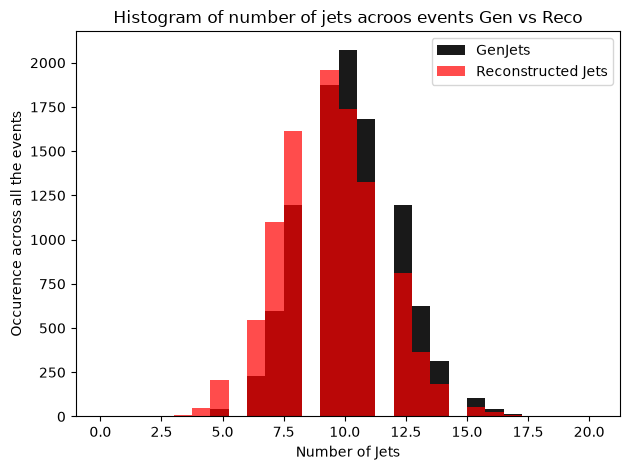

In [8]:
numGenJetsPerEvent = ak.num(GenJet["GenJet.PT"])
numJetsPerEvent = ak.num(Jet["Jet.PT"])
bins = np.arange(0,21,0.75)
plt.hist(numGenJetsPerEvent,bins=bins,label = f"GenJets",alpha = 0.9,histtype = 'stepfilled',color="Black")
plt.hist(numJetsPerEvent,bins = bins,label = f"Reconstructed Jets",alpha = 0.7,histtype = 'stepfilled',color="Red")
plt.legend()
plt.xlabel(f"Number of Jets")
plt.ylabel(f"Occurence across all the events")
plt.title("Histogram of number of jets acroos events Gen vs Reco")
plt.tight_layout()
plt.show()


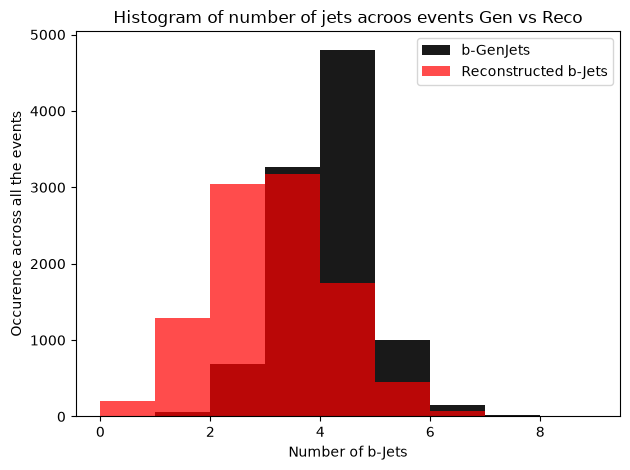

In [9]:
numB_JetsPerEvent = ak.sum(Jet["Jet.BTag"] != 0 ,axis = 1)
numB_GenJetsPerEvent = ak.sum(abs(GenJet["GenJet.Flavor"]) == 5,axis = 1)
bins = np.arange(0,10,1)
plt.hist(numB_GenJetsPerEvent,bins=bins,label = f"b-GenJets",alpha = 0.9,histtype = 'stepfilled',color = "#000000")
plt.hist(numB_JetsPerEvent,bins = bins,label = f"Reconstructed b-Jets",alpha = 0.7,histtype = 'stepfilled',color="#FF0000")
plt.legend()
plt.xlabel(f"Number of b-Jets")
plt.ylabel(f"Occurence across all the events")
plt.title("Histogram of number of jets acroos events Gen vs Reco")
plt.tight_layout()
plt.show()

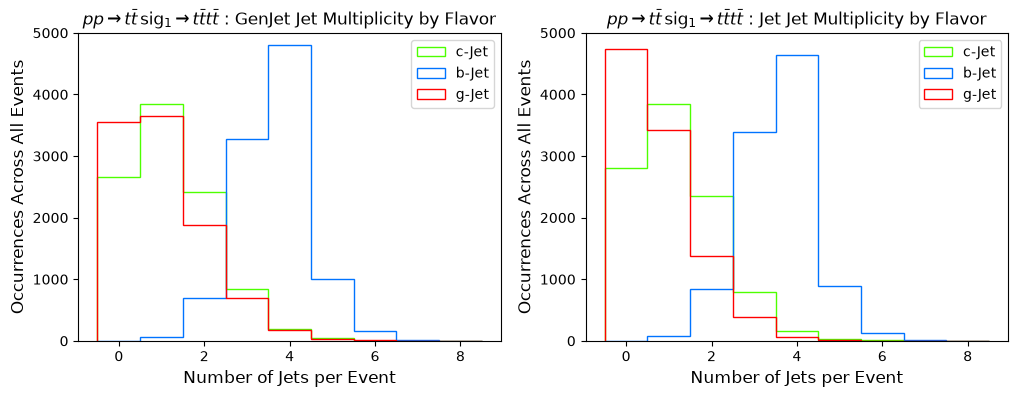

In [10]:
bins = np.arange(-0.5,9.5,1)
fig,ax = plt.subplots(1,2,figsize = (12,4))
jet_dict = {"GenJet":GenJet,"Jet" : Jet}
for i,(name,jets) in enumerate(jet_dict.items()):
    for color,flavor in zip(["#4DFF00","#0073ff","#ff0000"],[4,5,21]):
        numFlavourPerEvent = ak.sum(jets[f"{name}.Flavor"] == flavor , axis = 1)
        ax[i].hist(numFlavourPerEvent,bins = bins,color = color,alpha = 1,histtype = "step",
                label = f"{"b-Jet" if flavor == 5 else "c-Jet" if flavor == 4 else "g-Jet"}")
    ax[i].legend()
    ax[i].set_ylim(0,5000)
    ax[i].set_xlabel("Number of Jets per Event", fontsize=12)
    ax[i].set_ylabel("Occurrences Across All Events", fontsize=12)
    ax[i].set_title(fr"$p p \to t \bar{{t}} \, \mathrm{{sig}}_1 \to t\bar{{t}}t\bar{{t}}$ : {name} Jet Multiplicity by Flavor")
plt.show()


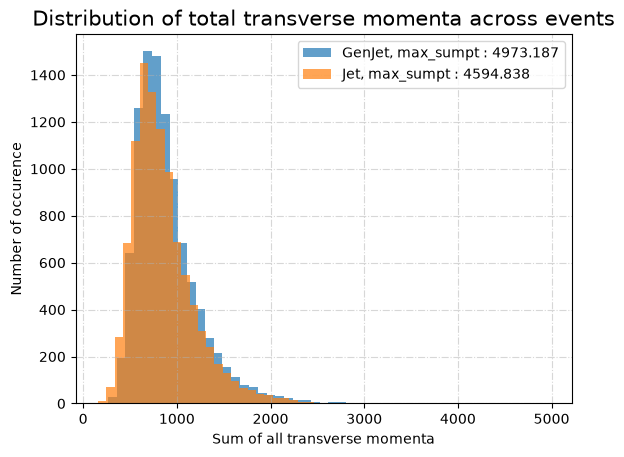

In [11]:
for name,data in jet_dict.items():
    jetsPtSum = ak.sum(data[f"{name}.PT"],axis = 1)
    plt.hist(jetsPtSum,bins = 50,alpha = 0.7,label = f"{name}, max_sumpt : {np.max(jetsPtSum):.3f}")
plt.legend()
plt.xlabel(f"Sum of all transverse momenta")
plt.ylabel(f"Number of occurence")
# plt.yscale("log")
plt.title("Distribution of total transverse momenta across events",fontsize = 15)
plt.grid(ls = "-.",alpha = 0.5)
plt.show()


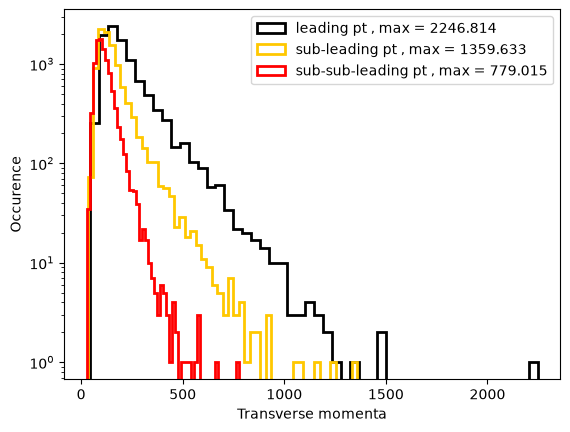

In [12]:
Jet["Jet.PT"][:,2]
for i,colour in zip(range(3),["#000000","#ffc800","#ff0000"]):
    jetPts = Jet["Jet.PT"][:,i]
    plt.hist(jetPts,bins = 50,
             label = f"{"leading" if i == 0 else "sub-leading" if i == 1 else "sub-sub-leading"} pt , max = {np.max(jetPts):.3f}",
             color = colour,
             histtype="step",
             lw = 2 )
plt.legend()
plt.xlabel("Transverse momenta")
plt.ylabel("Occurence")
plt.yscale("log")
plt.show()

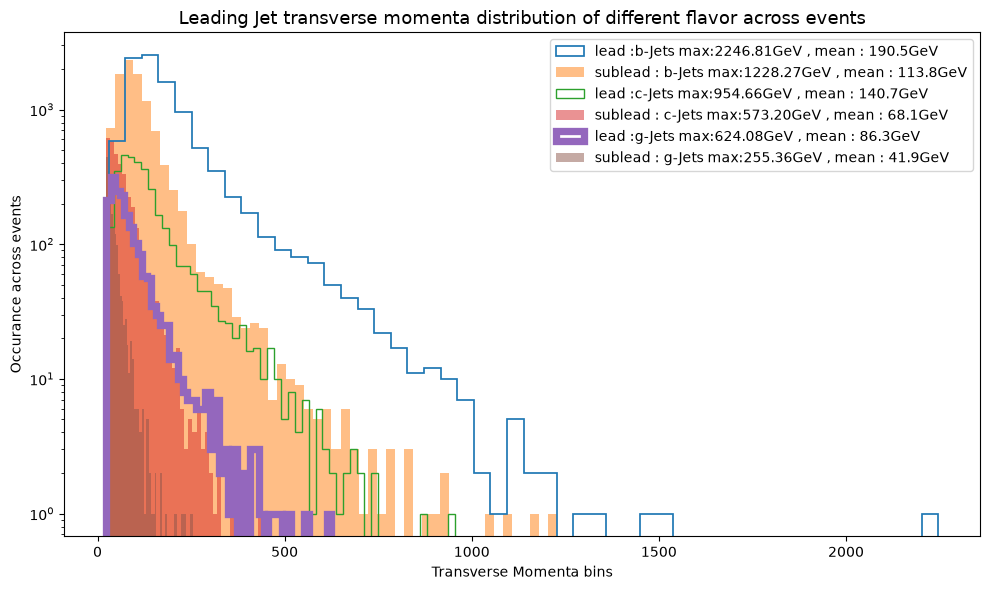

In [178]:
plt.figure(figsize = (10,6))
for flavor in [5,4,21]:
    jetpt = Jet["Jet.PT"][Jet["Jet.Flavor"] == flavor]
    trueJetPT = jetpt[ak.num(jetpt)>=2]
    leading = trueJetPT[:,0]
    subleading = trueJetPT[:,1]
    plt.hist(leading,bins = 50,histtype = "step",lw = flavor/4,
             label = f"lead :{ "b-Jets" if flavor == 5 else "c-Jets" if flavor == 4 else "g-Jets"} max:{np.max(leading):.2f}GeV , mean : {np.mean(leading):.1f}GeV")
    plt.hist(subleading,bins = 50,histtype="stepfilled",alpha = 0.5,
             label = f"sublead : {"b-Jets" if flavor == 5 else "c-Jets" if flavor == 4 else "g-Jets"} max:{np.max(subleading):.2f}GeV , mean : {np.mean(subleading):.1f}GeV")
plt.legend()
plt.yscale("log")
plt.xlabel("Transverse Momenta bins")
plt.ylabel("Occurance across events")
plt.title("Leading Jet transverse momenta distribution of different flavor across events",fontsize = 13)
plt.tight_layout()
plt.show()

In [14]:
np.where(ak.num(Jet["Jet.Eta"][Jet["Jet.Flavor"] == 5],axis = 1) == 0)

(<Array [1508, 2143, 9085, 9653] type='4 * int64'>,)

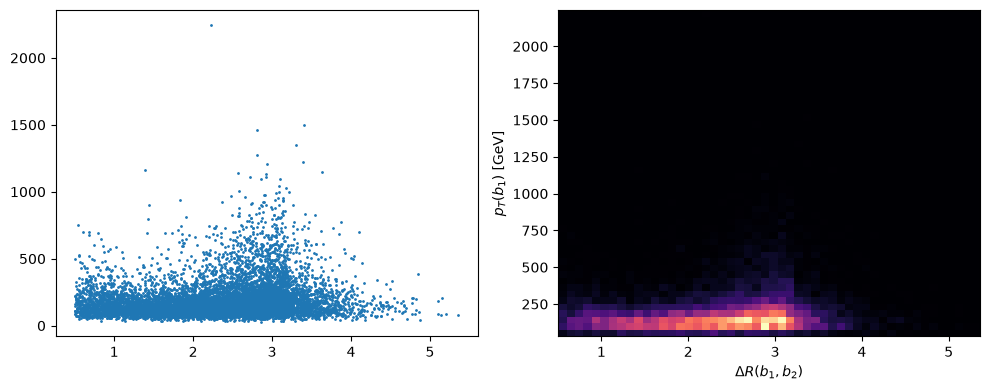

In [177]:
import vector
vector.register_awkward()

bJets = ak.zip(
    {
        "pt": Jet["Jet.PT"],
        "eta": Jet["Jet.Eta"],
        "phi": Jet["Jet.Phi"],
        "mass": Jet["Jet.Mass"],
    },
    with_name="Momentum4D",
    )[Jet["Jet.Flavor"] == 5]

bJetsAtLeast2 = bJets[ak.num(bJets) >= 2]

lead_bjet = bJetsAtLeast2[:,0]
sublead_bjet = bJetsAtLeast2[:,1]

delR = lead_bjet.deltaR(sublead_bjet)
leadPT = lead_bjet["pt"]

fig,ax = plt.subplots(1,2,figsize = (10,4))

ax[0].scatter(delR,leadPT,s = 1)
ax[1].hist2d(ak.to_numpy(delR),ak.to_numpy(leadPT),bins=(50, 50),cmap="magma")

plt.xlabel(r"$\Delta R(b_1,b_2)$")
plt.ylabel(r"$p_T(b_1)$ [GeV]")
plt.tight_layout()
# plt.colorbar(label="Events")
plt.show()

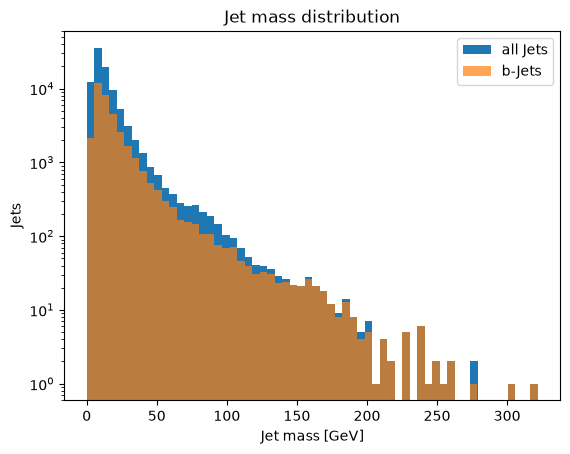

In [168]:
plt.hist(ak.to_numpy(ak.flatten(Jet["Jet.Mass"])),bins=60,label="all Jets")

bjet_mass = Jet["Jet.Mass"][Jet["Jet.Flavor"] == 5]
plt.hist(ak.to_numpy(ak.flatten(bjet_mass)),bins=60,label = "b-Jets",alpha = 0.7)

plt.xlabel("Jet mass [GeV]")
plt.ylabel("Jets")
plt.title("Jet mass distribution")
plt.yscale("log")
plt.legend()
plt.show()

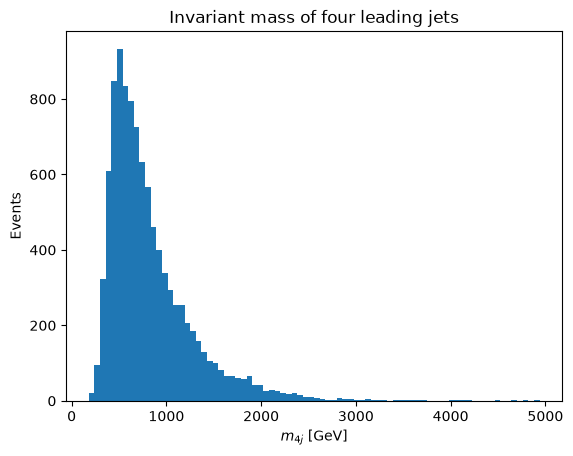

In [17]:
jets4 = ak.zip(
    {
        "pt": Jet["Jet.PT"],
        "eta": Jet["Jet.Eta"],
        "phi": Jet["Jet.Phi"],
        "mass": Jet["Jet.Mass"],
    },
    with_name="Momentum4D"
)

four_leading = jets4[:, :4]

M4j = ak.sum(four_leading, axis=1).mass

plt.hist(ak.to_numpy(M4j),bins=80)

plt.xlabel(r"$m_{4j}$ [GeV]")
plt.ylabel("Events")
plt.title("Invariant mass of four leading jets")
plt.show()

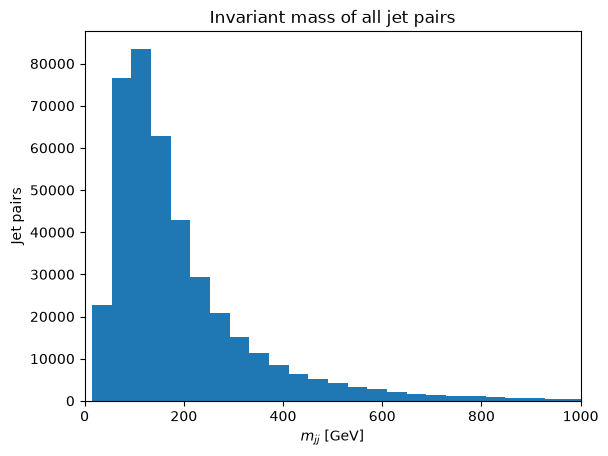

In [22]:
jet_pairs = ak.combinations(jets4, 2, fields=["j1", "j2"])

mjj = (jet_pairs["j1"] + jet_pairs["j2"]).mass

plt.hist(
    ak.to_numpy(ak.flatten(mjj)),
    bins=150
)

plt.xlabel(r"$m_{jj}$ [GeV]")
plt.ylabel("Jet pairs")
plt.title("Invariant mass of all jet pairs")
plt.xlim(0,1000)
plt.show()

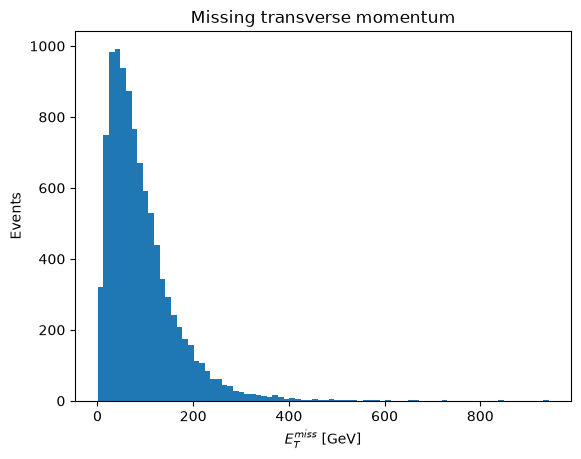

In [19]:
MET = tree["MissingET"]["MissingET.MET"].array(library="ak")

plt.hist(ak.to_numpy(MET),bins=80)


plt.xlabel(r"$E_T^{miss}$ [GeV]")
plt.ylabel("Events")
plt.title(r"Missing transverse momentum")
plt.show()

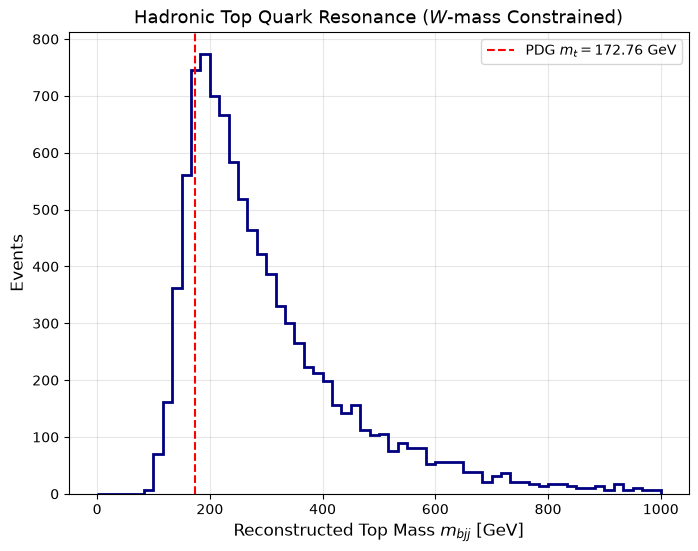

In [30]:

b_tag = tree["Jet/Jet.BTag"].array(library="ak")


b_jets = jets4[b_tag > 0]
light_jets = jets4[b_tag == 0]


mask = (ak.num(b_jets) >=1) & (ak.num(light_jets) >= 0)
b_jets = b_jets[mask]
light_jets = light_jets[mask]


pairs = ak.combinations(light_jets, 2)
j1, j2 = ak.unzip(pairs)
w_candidates = j1 + j2 


mW_pdg = 80.4
best_w_idx = ak.argmin((w_candidates.mass - mW_pdg)**2, axis=1, keepdims=True)
best_w = w_candidates[best_w_idx]
lead_best_w = best_w[:,0]

# 3. Add the leading b-jet to the best W candidate
best_b = b_jets[:, 0]
top_candidates = best_b + lead_best_w
m_top = top_candidates.mass

plt.figure(figsize=(8, 6))
plt.hist(m_top, bins=60,range = (0,1000), color='navy', histtype='step', linewidth=2)
plt.axvline(172.76, color='red', linestyle='--', label=r'PDG $m_t = 172.76\text{ GeV}$')
plt.xlabel(r'Reconstructed Top Mass $m_{bjj}$ [GeV]', fontsize=12)
plt.ylabel('Events', fontsize=12)
plt.title(r'Hadronic Top Quark Resonance ($W$-mass Constrained)', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

(array([  6.,   5.,   7.,  22.,  31.,  51.,  82.,  98., 137., 162., 230.,
        250., 320., 351., 402., 477., 500., 520., 509., 557., 517., 544.,
        506., 485., 408., 393., 356., 337., 300., 247., 201., 188., 165.,
        114., 110.,  89.,  78.,  51.,  39.,  29.,  25.,  27.,  19.,  12.,
         10.,   9.,   5.,   5.,   4.,   4.,   0.,   3.,   1.,   0.,   0.,
          0.,   0.,   0.,   1.,   1.]),
 array([0.39011592, 0.44835818, 0.50660044, 0.5648427 , 0.6230849 ,
        0.68132716, 0.73956943, 0.79781163, 0.85605395, 0.91429615,
        0.97253841, 1.03078067, 1.08902287, 1.1472652 , 1.2055074 ,
        1.2637496 , 1.32199192, 1.38023424, 1.43847632, 1.49671865,
        1.55496097, 1.61320329, 1.67144537, 1.72968769, 1.78793001,
        1.84617209, 1.90441442, 1.96265674, 2.02089882, 2.07914114,
        2.13738346, 2.19562578, 2.25386786, 2.31211019, 2.37035251,
        2.42859483, 2.48683691, 2.54507923, 2.60332155, 2.66156363,
        2.71980596, 2.77804828, 2.8362906 , 2.

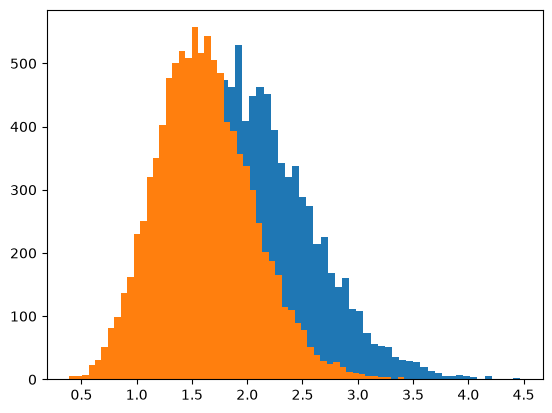

In [46]:
plt.hist(ak.sum(GenJet["GenJet.Mass"]/GenJet["GenJet.PT"],axis = 1),bins = 60)
plt.hist(ak.sum(Jet["Jet.Mass"]/Jet["Jet.PT"],axis = 1),bins = 60)

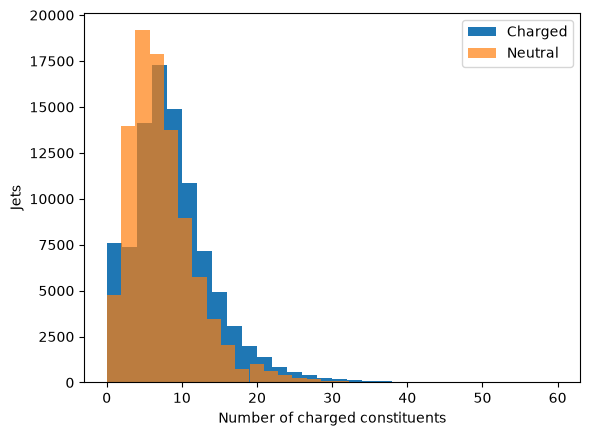

In [167]:
# Jet["Jet.NCharged"]
ncharged = ak.flatten(Jet["Jet.NCharged"])
nNeutral = ak.flatten(Jet["Jet.NNeutrals"])

plt.hist(ak.to_numpy(ncharged), bins=30,label = "Charged")
plt.hist(ak.to_numpy(nNeutral), bins=30,label = "Neutral",alpha = 0.7)
plt.xlabel("Number of charged constituents")
plt.ylabel("Jets")
plt.legend()
plt.show()

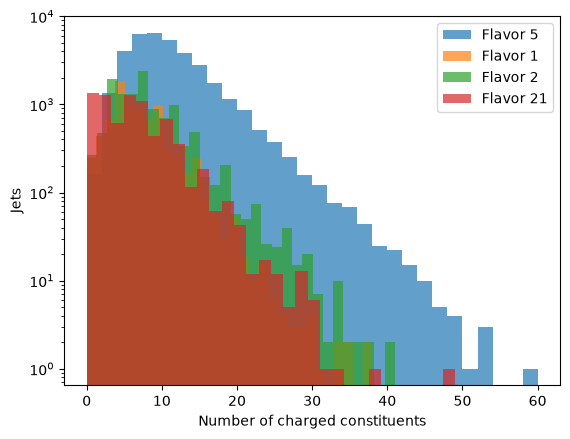

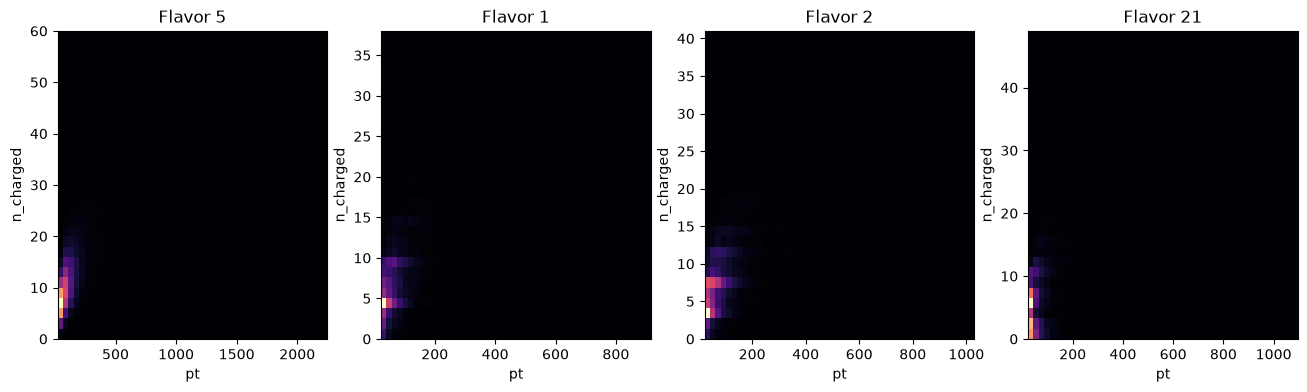

In [166]:
flavor = Jet["Jet.Flavor"]
ncharged = Jet["Jet.NCharged"]
pt = Jet["Jet.PT"]

# flatten both in the same way
flavor = ak.flatten(flavor)
ncharged = ak.flatten(ncharged)
pt = ak.flatten(pt)

for f in [5,1, 2, 21]:
    mask = flavor == f
    plt.hist(ak.to_numpy(ncharged[mask]),bins=30,alpha=0.7,label=f"Flavor {f}")
plt.ylabel("Jets")
plt.yscale("log")
plt.legend()
plt.xlabel("Number of charged constituents")
plt.show()


fig,ax = plt.subplots(1,4,figsize = (16,4))
for i,f in enumerate([5,1, 2, 21]):
    mask = flavor == f
    ax[i].hist2d(ak.to_numpy(pt[mask]),ak.to_numpy(ncharged[mask]),bins=(50, 30),cmap = "magma")
    ax[i].set_xlabel("pt")
    ax[i].set_ylabel("n_charged")
    ax[i].set_title(f"Flavor {f}")
plt.show()

